# Homework (Week 3) -- Biometrics (20 points)

In this homework we train Biometrics Verification model and use some features to increase quality:
1) Train ECAPA-TDNN (10 points)
2) Any contrastive loss (10 points)

Link to download dataset: https://disk.yandex.ru/d/lyhtieYbxQOYqw

In [36]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as torch_data
import torchaudio
import tqdm.notebook as tqdm
import urllib

import dataset

from IPython.display import clear_output

%matplotlib inline

In [37]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/lyhtieYbxQOYqw'
final_url = base_url + urllib.parse.urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']
# !wget -O voxceleb.tar.gz "{download_url}"
# !tar -xf voxceleb.tar.gz

### Some model train example

In [38]:
DEVICE = 'mps' # "cpu" for cpu, also you can use "cuda" for gpu and "mps" for apple silicon
DATADIR = 'data'
FEATS = 80
LOADER_WORKERS = 0

In [39]:
transform = torchaudio.transforms.MFCC(n_mfcc=FEATS) # You can try some other transformations here
trainset = dataset.Dataset(os.path.join(DATADIR, 'voxceleb_train'), transform)
testset = dataset.Dataset(os.path.join(DATADIR, 'voxceleb_test'), transform)
test_targets = pd.read_csv(os.path.join(DATADIR, 'target.csv')).values.tolist()

/Users/aleksandr.lukoianov/liablefish/speech_course/.venv/lib/python3.10/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [40]:
len(trainset), len(testset)

(67785, 4462)

### Models

In [41]:
class Model(nn.Module):
    def __init__(self, input_shape: int, output_shape: int, hidden: int, kernel: int = 7, sride: int = 2):
        super().__init__()
        self._emb = nn.Sequential(
            nn.Conv1d(input_shape, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.AdaptiveMaxPool1d(1),
        )
        self._final = nn.Sequential(
            nn.Linear(hidden, output_shape),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, X) -> tuple[torch.Tensor, torch.Tensor]:
        emb = self._emb(X).squeeze(2)
        return self._final(emb), emb

### Metrics

Cosine similarity:
$CS(a, b) = \frac{<a, b>}{\|a\| \|b\|}$

In [42]:
def cosine_similarity(a, b):
    a = a.reshape(-1)
    b = b.reshape(-1)
    return np.dot(a, b) / np.linalg.norm(a) / np.linalg.norm(b)

Here is O(N log N) algorithm for find best_eer:
1) Sort prediction by probability
2) Going through items and recalculating far and frr

In [43]:
def best_eer(data):
    full = sorted(data, key=lambda x: (x[0], -x[1]))
    pos = len([item for item in full if item[1] == 1])
    neg = len(full) - pos
    cur_pos = pos
    cur_neg = 0
    best_eer = 1
    for _, label in full:
        if label == 1:
            cur_pos -= 1
        else:
            cur_neg += 1
        cur_eer = max((pos - cur_pos) / pos, (neg - cur_neg) / neg)
        best_eer = min(best_eer, cur_eer)
    return best_eer

### Train

In [44]:
def train_stage(model, opt, batch_size: int = 256):
    loader = torch_data.DataLoader(
        trainset,
        shuffle=True,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    loss_sum = 0.0
    batches = 0
    for X, Y, _ in tqdm.tqdm(loader):
        logits, _ = model.forward(X.to(DEVICE))
        loss = F.nll_loss(logits, Y.to(DEVICE))
        loss_sum += loss.item()
        batches += 1
        opt.zero_grad()
        loss.backward()
        opt.step()
    return loss_sum / batches

In [45]:
def calc_eval_score(model: nn.Module, batch_size: int = 256):
    loader = torch_data.DataLoader(
        testset,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    items = {}
    target_scores = []
    with torch.no_grad():
        for X, _, pathes in tqdm.tqdm(loader):
            _, embds = model.forward(X.to(DEVICE))
            embds = embds.cpu().data.numpy().reshape(X.shape[0], -1)
            for embd, path in zip(embds, pathes):
                items[path] = embd
    for item1, item2, target in test_targets:
        target_scores.append((cosine_similarity(items[item1], items[item2]), target))
    return best_eer(target_scores)

In [46]:
def train(
    model: nn.Module,
    opt,
    batch_size: int = 256,
    epochs: int = 10,
    train_fun = train_stage,
    train_kwargs = {},
):
    train_losses = []
    eval_scores = []
    for epoch in range(epochs):
        model.train()
        train_losses.append(train_fun(model, opt, batch_size=batch_size))
        model.eval()
        eval_scores.append(calc_eval_score(model, batch_size=batch_size))
        clear_output()
        fig, axis = plt.subplots(1, 2, figsize=(15, 7))
        axis[0].plot(np.arange(1, epoch + 2), train_losses, label='train CE loss')
        axis[1].plot(np.arange(1, epoch + 2), eval_scores, label='eval')
        axis[0].set(xlabel='epoch', ylabel='CE Loss')
        axis[1].set(xlabel='epoch', ylabel='EER')
        fig.legend()
        plt.show()
        print(f'Epoch {epoch + 1}. Train loss {train_losses[-1]}. Eval score {eval_scores[-1]}')

In [47]:
# model = Model(FEATS, trainset.speakers(), 128).to(DEVICE)
# opt = optim.Adam(model.parameters())
# train(model, opt)

In [48]:
dummy_loader = torch_data.DataLoader(
    trainset,
    shuffle=False,
    batch_size=128,
    collate_fn=dataset.collate_fn,
    num_workers=LOADER_WORKERS,
)
dummy_batch = next(iter(dummy_loader))
print(dummy_batch[0].shape, dummy_batch[1].shape)

torch.Size([128, 80, 791]) torch.Size([128])


### ECAPA TDNN (10 points)

Paper: https://arxiv.org/pdf/2005.07143.pdf

Papers for ECAPA parts:
- SE-Blocks - https://arxiv.org/pdf/1709.01507.pdf
- Res2Net - https://arxiv.org/pdf/1904.01169.pdf
- Attentive Stats Pooling - https://arxiv.org/pdf/1803.10963.pdf
- AAM Softmax - https://arxiv.org/pdf/1906.07317.pdf

Also you can optionally add other settings for paper:
- SpecAug
- Weight decay for optimizer
- LR scheduler

In [49]:
class SEBlock(nn.Module):
    def __init__(self, input_shape: int, reduction: int):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(in_features=input_shape, out_features=reduction),
            nn.ReLU(),
            nn.Linear(in_features=reduction, out_features=input_shape),
            nn.Sigmoid()
        )

    def forward(self, X):
        # X: [batch_size, input_shape, T]
        # out: [batch_size, input_shape, T]
        squeezed = self.squeeze(X).squeeze(-1) # [batch_size, input_shape]
        weights = self.excitation(squeezed) # [batch_size, input_shape]
        return X * weights.unsqueeze(-1)


In [50]:
class Res2Net(nn.Module):
    def __init__(self, hidden: int, dilation: int, scale: int, kernel_size: int):
        super().__init__()
        assert hidden % scale == 0
        assert scale > 1
        self.scale = scale
        self.frontend = nn.Conv1d(hidden, hidden, kernel_size=1)
        self.backend = nn.Conv1d(hidden, hidden, kernel_size=1)
        self.filters = nn.ModuleList(
            [
                nn.Conv1d(hidden // scale, hidden // scale, kernel_size=kernel_size, dilation=dilation, stride=1, padding="same")
                for _ in range(scale - 1)
            ]
        )
        self.batch_norms = nn.ModuleList(
            [
                nn.BatchNorm1d(hidden // scale)
                for _ in range(scale - 1)
            ]
        )
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.frontend(X)
        _, hidden, _ = X.shape
        X_groups = torch.split(X, hidden // self.scale, dim=1) # scale x [batch_size, feats // scale, time]
        outs = []
        for i, group in enumerate(X_groups):
            if i == 0:
                outs.append(group)
                continue
            
            input_ = group
            if i > 1:
                input_ = input_ + outs[i - 1]
            
            out = self.relu(self.batch_norms[i - 1](self.filters[i - 1](input_)))
            outs.append(out)

        out = torch.cat(outs, dim=1) # [batch_size, feats, time]
        out = self.backend(out)
        return out


In [51]:
class EcapaBlock(nn.Module):
    def __init__(self, hidden: int, kernel_size: int, dilation: int, scale: int):
        super().__init__()
        # Note:
        # "The first dense layer can be used to reduce
        # the feature dimension, while the second dense layer restores the
        # number of features to the original dimension"
        self.frontend = nn.Sequential(
            nn.Conv1d(hidden, hidden, kernel_size=1, dilation=1, stride=1, padding=0),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
        )
        self.res2net = nn.Sequential(
            Res2Net(hidden, dilation=dilation, scale=scale, kernel_size=kernel_size),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
        )
        self.backend = nn.Sequential(
            nn.Conv1d(hidden, hidden, kernel_size=1, dilation=1, stride=1, padding=0),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
        )
        self.se_block = SEBlock(hidden, reduction=128) 

    def forward(self, X):
        X = self.frontend(X)
        X = self.res2net(X)
        X = self.backend(X)
        X = self.se_block(X)
        return X

In [52]:
class AttentiveStatsPooling(nn.Module):
    def __init__(self, input_shape: int, hidden: int):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv1d(3 * input_shape, hidden, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(hidden, input_shape, kernel_size=1),
            nn.Softmax(dim=-1),
        )

    def forward(self, X):
        # X shape = [feats, time]
        # calc mean and std for X over time dimension
        # concatenate mean and std to X over feats dimension to make shape [feats * 3, time]
        # attention
        # weighted mean and std with weights from attention for original X
        _, _, t = X.shape
        global_X = torch.cat([X, X.mean(-1, keepdim=True).repeat(1, 1, t), X.std(-1, keepdim=True).repeat(1, 1, t)], dim=1) # [batch_size, 3 * feats, time]
        weights = self.attention(global_X) # [batch_size, 3 * feats, time]
        mean = torch.sum(X * weights, dim=-1) # [batch_size, feats]
        std = torch.sqrt((torch.sum(weights * X ** 2, dim=-1) - mean ** 2).clamp(min=1e-10)) # [batch_size, feats]
        return torch.cat([mean, std], dim=-1)


In [53]:
import math

class AAMSoftmax(nn.Module):
    def __init__(self, input_shape, n_class, margin, scale):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(n_class, input_shape))
        nn.init.xavier_uniform_(self.weight)
        self.margin = margin
        self.scale = scale

        # cos(\theta + m)=cos\theta * cosm − sin\theta * sinm
        self.cos_m = math.cos(self.margin)
        self.sin_m = math.sin(self.margin)

        # Easy margin threshold: cos(pi - m)
        self.th = math.cos(math.pi - self.margin)
        self.mm = math.sin(math.pi - self.margin) * self.margin

    def forward(self, X):
        # calc cosine similarity between X and weights
        # theta = angle from cosine similarity
        # return matrix S, where S_ij =
        #     \log \frac{
        #         \exp{scale \cos{theta_ij + margin}}
        #     }{
        #         \exp{scale \cos{theta_ij + margin}} + \sum_{k != j} \exp{scale \cos{theta_ik}}
        #     }
        # S_ij = scale \cos{theta_ij + margin} - log(\exp{scale \cos{theta_ij + margin}} + sum(\exp{scale \cos{theta_kn}) - \exp{scale \cos{theta_ij})
        # X: [batch_size, input_shape]
        # out: [batch_size, n_class]
        cos = F.linear(F.normalize(X), F.normalize(self.weight))
        sin = torch.sqrt((1.0 - cos.clamp(-1, 1) ** 2).clamp(min=1e-10))
        cos_with_margin = cos * self.cos_m - sin * self.sin_m

        # Easy margin: fall back to cos - mm when theta + m > pi
        cos_with_margin = torch.where(cos > self.th, cos_with_margin, cos - self.mm)

        scaled_cos_with_margin = self.scale * cos_with_margin
        scaled_cos = self.scale * cos

        # Numerically stable log-sum-exp for the denominator
        # denominator_j = log(exp(scaled_cos_with_margin_j) + sum_{k!=j} exp(scaled_cos_k))
        #               = log(exp(scaled_cos_with_margin_j) + sum(exp(scaled_cos)) - exp(scaled_cos_j))
        all_logsum = torch.logsumexp(scaled_cos, dim=-1, keepdim=True)  # log(sum(exp(scaled_cos)))
        # log(sum_{k!=j} exp(scaled_cos_k)) = log(sum(exp(scaled_cos)) - exp(scaled_cos_j))
        #   Use: log(exp(a) - exp(b)) = a + log(1 - exp(b - a))
        log_sum_except_j = all_logsum + torch.log1p(-torch.exp(scaled_cos - all_logsum))
        # denominator = log(exp(scaled_cos_with_margin) + exp(log_sum_except_j))
        denominator = torch.logaddexp(scaled_cos_with_margin, log_sum_except_j)

        return scaled_cos_with_margin - denominator


In [54]:
class EcapaTDNN(nn.Module):
    def __init__(self, input_shape: int, output_shape: int, hidden: int):
        super().__init__()
        self.frontend = nn.Sequential(
            nn.Conv1d(input_shape, hidden, kernel_size=5, dilation=1, stride=1, padding=0),
            nn.ReLU(),
            nn.BatchNorm1d(hidden)
        )
        # EcapaBlock a.k.a SE-Res2Block
        self.ecapa_1 = EcapaBlock(hidden, kernel_size=3, dilation=2, scale=8)
        self.ecapa_2 = EcapaBlock(hidden, kernel_size=3, dilation=3, scale=8)
        self.ecapa_3 = EcapaBlock(hidden, kernel_size=3, dilation=4, scale=8)
        # Multi-layer Feature Aggregation
        self.mfa = nn.Sequential(
            nn.Conv1d(3 * hidden, 1536, kernel_size=1, dilation=1, stride=1, padding=0),
            nn.ReLU()
        )
        self.pooling = nn.Sequential(
            AttentiveStatsPooling(input_shape=1536, hidden=128),
            nn.BatchNorm1d(3072)
        )
        self.fc = nn.Sequential(
            nn.Linear(in_features=3072, out_features=192),
            nn.BatchNorm1d(192)
        )
        self.softmax = AAMSoftmax(input_shape=192, n_class=output_shape, margin=0.2, scale=32)#scale=32)

    def forward(self, X):
        # X: [batch_size, input_shape, time]
        # out: [batch_size, output_shape]
        X = self.frontend(X) # [batch_size, hidden, T]

        X_1 = self.ecapa_1(X) + X
        X_2 = self.ecapa_2(X_1) + X_1
        X_3 = self.ecapa_3(X_2) + X_2 # [batch_size, hidden, T]

        X = torch.cat([X_1, X_2, X_3], dim=1)  # [batch_size, 3 * hidden, T]
        X = self.mfa(X) # [batch_size, 1536, T]
        X = self.pooling(X).squeeze(-1) # [batch_size, 3072]
        X = self.fc(X) # [batch_size, 192]
        logits = self.softmax(X)

        return logits, X

Train ECAPA model, at this point you can archive stable score (for several consecutive epochs) near 0.08 EER.

You can train ECAPA with hidden size 256 to increase speed

In [55]:
model = EcapaTDNN(FEATS, trainset.speakers(), 128).to(DEVICE)

In [56]:
dummy_logits, dummy_embed = model(dummy_batch[0].to(DEVICE))

In [57]:
dummy_logits.shape, dummy_embed.shape

(torch.Size([128, 1211]), torch.Size([128, 192]))

In [58]:
F.nll_loss(dummy_logits, dummy_batch[1].to(DEVICE))

tensor(16.0373, device='mps:0', grad_fn=<NllLossBackward0>)

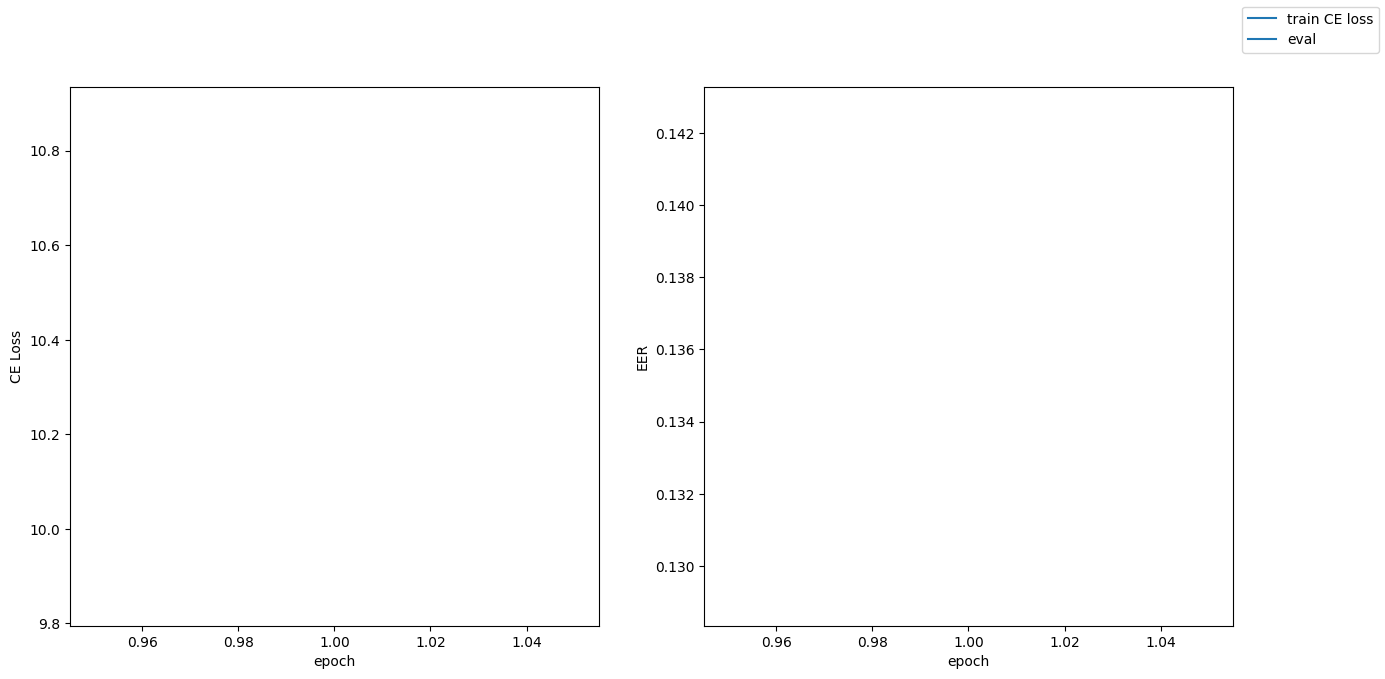

Epoch 1. Train loss 10.365027104683643. Eval score 0.13581260260133854


  0%|          | 0/530 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [59]:
model = EcapaTDNN(FEATS, trainset.speakers(), 256).to(DEVICE)
opt = optim.Adam(model.parameters())
train(model, opt, batch_size=128)

In [ ]:
# Save model to preserve results before uptraining experiments
torch.save(model, 'model.pt')

### Contrastive losses (10 points)

You can use anyone constrative loss.
Good article with contrastive losses https://lilianweng.github.io/posts/2021-05-31-contrastive/

Base losses:
- contrastive
- triplet -- it gives a better quality usually
- lifted structured loss -- better batch data utilization

The main problem with contrastive loss is the positive pairs sampler.
This is because a large number of classes provided only once per batch
in case of large number of classes in the dataset.

In [ ]:
class PositivePairsSampler(torch.utils.data.Sampler):
    def __init__(self, speakers: list[int], batch_size: int):
        pass
        # <YOUR CODE IS HERE>

    def __len__(self):
        pass
        # <YOUR CODE IS HERE>

    def __iter__(self):
        # yield __len__ batches as list of indexes of samples from dataset
        # <YOUR CODE IS HERE>
        for _ in range(len(self)):
            indexes = []
            # <YOUR CODE IS HERE>
            yield indexes

In [ ]:
def contrastive_train_stage(model, opt, batch_size: int = 256):
    # You can use any contrastive loss here to improve training
    # You can combine contrastive loss with the NLL loss after AAM softmax to improve stability
    loader = torch_data.DataLoader(
        trainset,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
        batch_sampler=PositivePairsSampler(trainset._speakers, batch_size)
    )
    # <YOUR CODE IS HERE>

Train model with contrastive loss here. At this point you can archive EER near 0.06-0.07 (it should be at least on 0.005 to 0.01 better than before)

In [ ]:
model = torch.load('model.pt').to(DEVICE)
opt = optim.Adam(model.parameters())
train(model, opt, batch_size=128, train_fun=contrastive_train_stage)